# Census tract IDs: why the join with the polygon data loses trips

While building the census tract demand tables we noticed that a lot of trips get lost when joining `pickup_census_tract` against the tract polygons. This notebook digs into why.

There are really two separate questions here: does the tract ID from the taxi data exist in our polygon table at all, and does the pickup point actually lie inside one of the polygons? A failed ID join doesn't automatically mean the trip happened outside Chicago, it can just as well be an ID mismatch between two dataset versions.

## Things to keep in mind

The pickup coordinates in the taxi data are not exact positions. For privacy reasons the city only publishes the centroid of the census tract (or community area), so many trips share the same point. When we assign a point to a polygon below, we are locating this published centroid, not the real pickup.

Also, the data doesn't tell us which Census vintage the taxi IDs come from. The split-tract examples further down are pretty convincing evidence for a version mismatch, but we can't prove it for every single ID. Because of that we keep the original ID and the spatially reconstructed one as separate columns instead of overwriting anything.

In [1]:
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from run_config import PATHS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

TRIPS_PATH = Path(PATHS.gold_taxi_trips)
CENSUS_POLYGONS_PATH = Path(PATHS.silver_census_tracts)
for required_path in (TRIPS_PATH, CENSUS_POLYGONS_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

con = duckdb.connect()
con.execute("SET threads = 4")
con.execute(
    f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{TRIPS_PATH.as_posix()}')"
)

census_polygons = gpd.read_parquet(CENSUS_POLYGONS_PATH)
if census_polygons.crs is None:
    raise ValueError("Census polygons must have a defined CRS")

polygon_ids = (
    pd.to_numeric(census_polygons["CENSUS_T_1"], errors="coerce")
    .dropna().astype("int64").drop_duplicates()
)
con.register("valid_polygon_ids", pd.DataFrame({"census_tract": polygon_ids}))

print(f"Trips: {con.sql('SELECT COUNT(*) FROM trips').fetchone()[0]:,}")
print(f"Census polygons: {len(census_polygons):,}")
print(f"Polygon CRS: {census_polygons.crs}")

Trips: 13,387,586
Census polygons: 878
Polygon CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction

## How bad is the direct ID join?

First we reproduce the join the gold pipeline currently does: a taxi tract ID counts as a match only if exactly the same number appears in the polygon table.

,all_trips,census_code_present,census_id_matches_polygon,census_id_not_in_polygon_table,code_present_pct_all,direct_match_pct_all,direct_match_pct_of_codes
0,13387586,6050103,2830710,3219393,45.19,21.14,46.79


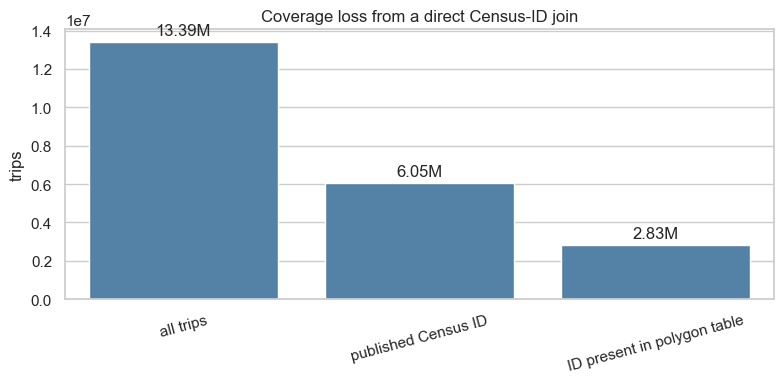

In [2]:
id_coverage = con.sql("""
    SELECT
        COUNT(*) AS all_trips,
        COUNT(*) FILTER (WHERE t.pickup_census_tract IS NOT NULL)
            AS census_code_present,
        COUNT(*) FILTER (WHERE p.census_tract IS NOT NULL)
            AS census_id_matches_polygon,
        COUNT(*) FILTER (
            WHERE t.pickup_census_tract IS NOT NULL AND p.census_tract IS NULL
        ) AS census_id_not_in_polygon_table
    FROM trips t
    LEFT JOIN valid_polygon_ids p
        ON t.pickup_census_tract = p.census_tract
""").df()
id_coverage["code_present_pct_all"] = 100 * id_coverage.census_code_present / id_coverage.all_trips
id_coverage["direct_match_pct_all"] = 100 * id_coverage.census_id_matches_polygon / id_coverage.all_trips
id_coverage["direct_match_pct_of_codes"] = (
    100 * id_coverage.census_id_matches_polygon / id_coverage.census_code_present
)
display(id_coverage.round(2))

coverage_plot = pd.DataFrame({
    "stage": ["all trips", "published Census ID", "ID present in polygon table"],
    "trips": [
        id_coverage.at[0, "all_trips"],
        id_coverage.at[0, "census_code_present"],
        id_coverage.at[0, "census_id_matches_polygon"],
    ],
})
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=coverage_plot, x="stage", y="trips", color="steelblue")
ax.set(title="Coverage loss from a direct Census-ID join", xlabel="", ylabel="trips")
ax.tick_params(axis="x", rotation=15)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value / 1e6:.2f}M" for value in coverage_plot.trips], padding=3)
plt.tight_layout()
plt.show()

So the direct join loses trips for two different reasons: either the taxi record has no tract ID at all, or it has one that simply doesn't exist in our polygon table. Neither case tells us where the pickup point actually is.

## Where do the published points actually fall?

Joining 13M individual points against polygons would be slow and pointless, since the privacy centroids repeat constantly. So we first group the trips by unique (pickup location, tract ID) combination and keep a `trips` count as weight.

In [3]:
published_locations = con.sql("""
    SELECT
        pickup_centroid_location AS location_id,
        pickup_centroid_latitude AS latitude,
        pickup_centroid_longitude AS longitude,
        pickup_census_tract AS published_census_id,
        COUNT(*) AS trips
    FROM trips
    WHERE pickup_centroid_latitude IS NOT NULL
      AND pickup_centroid_longitude IS NOT NULL
    GROUP BY 1, 2, 3, 4
""").df()

published_points = gpd.GeoDataFrame(
    published_locations,
    geometry=gpd.points_from_xy(
        published_locations.longitude,
        published_locations.latitude,
    ),
    crs="EPSG:4326",
)
if published_points.crs != census_polygons.crs:
    published_points = published_points.to_crs(census_polygons.crs)

spatial_join = gpd.sjoin(
    published_points,
    census_polygons[["CENSUS_T_1", "geometry"]],
    how="left",
    predicate="within",
).rename(columns={"CENSUS_T_1": "spatial_census_id"})

spatial_join["published_census_id"] = pd.to_numeric(
    spatial_join.published_census_id, errors="coerce"
).astype("Int64")
spatial_join["spatial_census_id"] = pd.to_numeric(
    spatial_join.spatial_census_id, errors="coerce"
).astype("Int64")

spatial_join["status"] = "published ID differs from containing polygon"
spatial_join.loc[spatial_join.published_census_id.isna(), "status"] = "published ID missing"
spatial_join.loc[spatial_join.spatial_census_id.isna(), "status"] = "point outside polygon grid"
spatial_join.loc[
    spatial_join.published_census_id.eq(spatial_join.spatial_census_id).fillna(False),
    "status",
] = "exact ID and polygon match"

status_order = [
    "exact ID and polygon match",
    "published ID differs from containing polygon",
    "published ID missing",
    "point outside polygon grid",
]
status_summary = (
    spatial_join.groupby("status", dropna=False)
    .agg(unique_location_records=("location_id", "size"), trips=("trips", "sum"))
    .reindex(status_order, fill_value=0)
    .reset_index()
)
status_summary["trip_share_pct"] = 100 * status_summary.trips / status_summary.trips.sum()
display(status_summary.round(2))

,status,unique_location_records,trips,trip_share_pct
0,exact ID and polygon match,304,2830710,21.14
1,published ID differs from containing polygon,164,3219393,24.05
2,published ID missing,77,7337483,54.81
3,point outside polygon grid,0,0,0.00


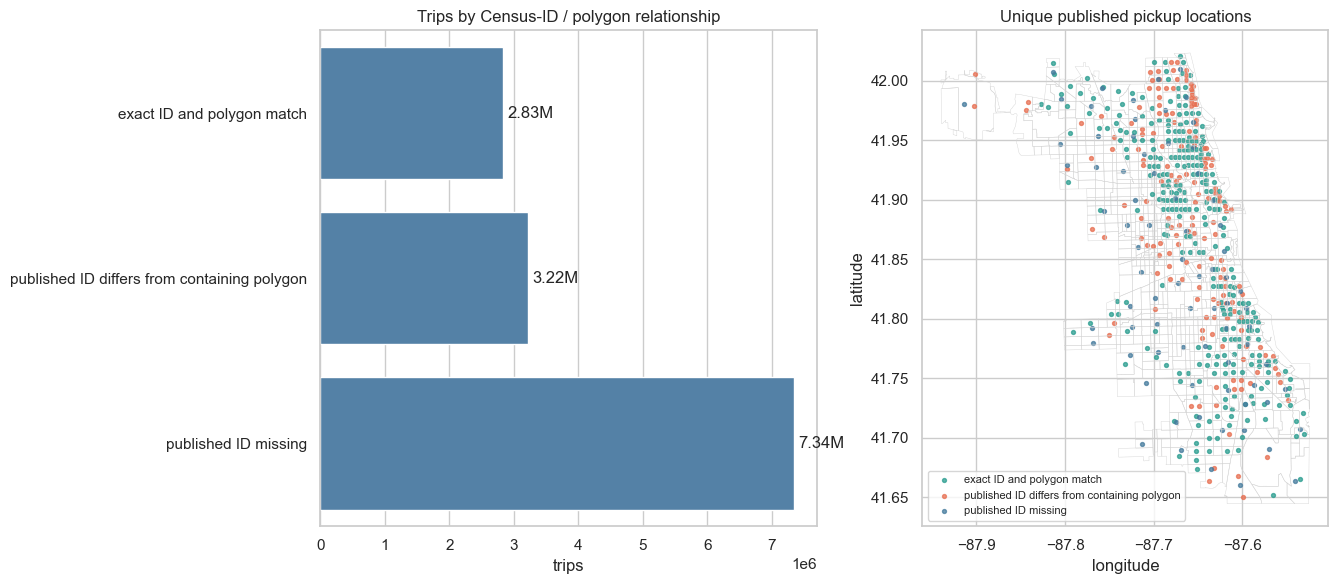

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_summary = status_summary[status_summary.trips > 0].copy()
sns.barplot(data=plot_summary, y="status", x="trips", color="steelblue", ax=axes[0])
axes[0].set(title="Trips by Census-ID / polygon relationship", xlabel="trips", ylabel="")
for container in axes[0].containers:
    axes[0].bar_label(container, labels=[f"{value / 1e6:.2f}M" for value in plot_summary.trips], padding=3)

colors = {
    "exact ID and polygon match": "#2a9d8f",
    "published ID differs from containing polygon": "#e76f51",
    "published ID missing": "#457b9d",
    "point outside polygon grid": "#6c757d",
}
census_polygons.boundary.plot(ax=axes[1], color="lightgray", linewidth=0.3)
for status, frame in spatial_join.groupby("status"):
    frame.plot(
        ax=axes[1], color=colors[status], markersize=8,
        alpha=0.75, label=status,
    )
axes[1].set(title="Unique published pickup locations", xlabel="longitude", ylabel="latitude")
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

## Which IDs are causing the mismatch?

Top published tract IDs that don't exist in the polygon table, sorted by trip volume. `spatial_census_id` is the polygon the point actually falls into.

In [5]:
top_mismatches = (
    spatial_join.loc[
        spatial_join.status == "published ID differs from containing polygon",
        [
            "published_census_id", "spatial_census_id",
            "latitude", "longitude", "trips",
        ],
    ]
    .sort_values("trips", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
top_mismatches["share_of_all_mismatching_trips_pct"] = (
    100 * top_mismatches.trips
    / spatial_join.loc[
        spatial_join.status == "published ID differs from containing polygon", "trips"
    ].sum()
)
display(top_mismatches.round({"latitude": 6, "longitude": 6, "share_of_all_mismatching_trips_pct": 2}))

,published_census_id,spatial_census_id,latitude,longitude,trips,share_of_all_mismatching_trips_pct
0,17031980000,17031760900,41.979071,-87.903040,1345178,41.78
1,17031839100,17031320300,41.880994,-87.632746,647897,20.12
2,17031081401,17031081400,41.895033,-87.619711,266428,8.28
3,17031081403,17031081400,41.890922,-87.618868,204332,6.35
4,17031980100,17031561200,41.785999,-87.750934,179838,5.59
5,17031081201,17031081200,41.899156,-87.626211,166897,5.18
6,17031081402,17031081400,41.891972,-87.612945,81768,2.54
7,17031841000,17031330400,41.849247,-87.624135,69722,2.17
8,17031833000,17031280300,41.885281,-87.657233,57481,1.79
9,17031081202,17031081200,41.902788,-87.626146,45779,1.42


The pattern is quite clear: IDs like `17031081401`, `-02` and `-03` all land inside polygon `17031081400`, and `17031081201`/`-02` inside `17031081200`. That's exactly what tract splits between Census vintages look like, the taxi data uses newer split IDs, our polygon file has the older parents.

The biggest single offender is `17031980000` with 1.3M trips: that's the O'Hare special-use tract. For those airport/downtown centroids the privacy aggregation plays a role too, so we wouldn't over-interpret each individual assignment.